<a href="https://colab.research.google.com/github/Nik8x/Sentiment140/blob/master/twitter_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import regex as re

import os

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelBinarizer

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import LSTM
from keras.utils import np_utils
from keras.callbacks import EarlyStopping

from keras.preprocessing.text import Tokenizer
from keras.utils.np_utils import to_categorical

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Embedding

from keras.preprocessing.text import Tokenizer
from keras.utils.np_utils import to_categorical

Using TensorFlow backend.


In [2]:
# Any results you write to the current directory are saved as output.
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
os.chdir("/content/gdrive/My Drive/Colab Notebooks/")
print("The current directory is: ", os.getcwd())

The current directory is:  /content/gdrive/My Drive/Colab Notebooks


In [0]:
# lets start 

In [5]:
sent = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding = 'latin-1', header = None)
sent.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
sent.head()

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [6]:
sent.target.value_counts()

4    800000
0    800000
Name: target, dtype: int64

In [7]:
sent.shape

(1600000, 6)

In [8]:
# looking at the first tweet
sent.text[0]

"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"

In [0]:
# well, it needs cleaning, we dont want to give our model, @ or hashtags or links or even emojis

In [0]:
def clean(tweet):
  
  t_clean = re.sub('@.*? ', '', tweet)
  t_clean = re.sub(r'@\_.*? ', '', t_clean)
  
  t_clean = re.sub(r'http://.*?($| )', '', t_clean)
  t_clean = t_clean.replace('"', '')
  t_clean = t_clean.replace("'", '')
  t_clean = t_clean.replace('  ', ' ')
  t_clean = re.sub(r'^ +', '' , t_clean)
  
  t_clean = t_clean.lower()

  return t_clean

In [11]:
clean(sent.text[19])

'oh dear. were you drinking out of the forgotten table drinks? '

In [12]:
%%time
tweets = sent.text.apply(clean)

CPU times: user 20.1 s, sys: 1.44 s, total: 21.5 s
Wall time: 21.5 s


In [13]:
tweets[0:5]

0    - awww, thats a bummer. you shoulda got david ...
1    is upset that he cant update his facebook by t...
2    i dived many times for the ball. managed to sa...
3      my whole body feels itchy and like its on fire 
4    no, its not behaving at all. im mad. why am i ...
Name: text, dtype: object

In [0]:
# let's tokenize the tweets

In [0]:
# import gensim

In [0]:
# %%time
# # build vocabulary and train model
# model = gensim.models.Word2Vec(
#         tweets,
#         size=150,
#         window=10,
#         min_count=2,
#         workers=10)

# %%time
# #model. (tweets, total_examples = len(tweets), epochs=10)
# print(model)

In [0]:
# %%time

# words = list(model.wv.vocab)
# len(words)

In [0]:
#vectorizer = CountVectorizer(ngram_range=(1, 5))

In [0]:
#combine everything any apply tokkenizer, then convert all the words to vectors

In [0]:
# %time
# tweets_vector = vectorizer.fit_transform(tweets)

In [0]:
tweets_1 = ''.join(tweets)

In [22]:
len(tweets_1)

105875306

In [23]:
tweets_1[0:1000]

'- awww, thats a bummer. you shoulda got david carr of third day to do it. ;dis upset that he cant update his facebook by texting it... and might cry as a result school today also. blah!i dived many times for the ball. managed to save 50% the rest go out of boundsmy whole body feels itchy and like its on fire no, its not behaving at all. im mad. why am i here? because i cant see you all over there. not the whole crew need a hug hey long time no see! yes.. rains a bit ,only a bit lol , im fine thanks , hows you ?nope they didnt have it que me muera ? spring break in plain city... its snowing i just re-pierced my ears i couldnt bear to watch it. and i thought the ua loss was embarrassing . . . . .it it counts, idk why i did either. you never talk to me anymore i wouldve been the first, but i didnt have a gun.  not really though, zac snyders just a doucheclown.i wish i got to watch it with you!! i miss you and how was the premiere?!hollis death scene will hurt me severely to watch on film

In [24]:
%%time
# integer encode text
tokenizer = Tokenizer()
tokenizer.fit_on_texts([tweets_1])
encoded = tokenizer.texts_to_sequences([tweets_1])[0]

CPU times: user 48.5 s, sys: 1.54 s, total: 50.1 s
Wall time: 50.1 s


In [25]:
# determine the vocabulary size
vocab_size = len(tokenizer.word_index) + 1
print('Vocabulary Size: %d' % vocab_size)

Vocabulary Size: 388286


In [26]:
len(tokenizer.word_index)

388285

In [27]:
tokenizer.texts_to_sequences([tweets[0]])[0]

[488, 103, 4, 1255, 7, 3496, 49, 870, 10145, 12, 1896, 31, 2, 41, 9, 435]

In [0]:
# don't use this way, it will exceed ram
# %%time
# tweets_token = tweets.apply(tokenizer.texts_to_sequences)

In [29]:
%%time
tweets_token = tweets.apply(lambda x: tokenizer.texts_to_sequences([x])[0])

CPU times: user 42 s, sys: 11.6 ms, total: 42 s
Wall time: 42 s


In [30]:
tweets_token[0]

[488, 103, 4, 1255, 7, 3496, 49, 870, 10145, 12, 1896, 31, 2, 41, 9, 435]

In [31]:
len(tweets), type(tweets)

(1600000, pandas.core.series.Series)

In [32]:
# let's look at the length of each row
for i in tweets_token[0:10]:
  print(len(i))  

16
21
17
10
20
4
3
18
5
3


In [33]:
%%time
listy = []
for i in tweets_token:
  listy.append(i)
  
print(len(listy))

1600000
CPU times: user 332 ms, sys: 797 µs, total: 333 ms
Wall time: 339 ms


In [34]:
%%time
length = len(sorted(listy[1:], key = len, reverse = True)[0])   # creating array by adding 0 to make all rows equal
X = np.array([xi + [0] * (length - len(xi)) for xi in listy[0:]])
print(X.shape)  # creating X array

(1600000, 118)
CPU times: user 21.8 s, sys: 16.1 s, total: 37.9 s
Wall time: 37.8 s


In [35]:
X[0]

array([  488,   103,     4,  1255,     7,  3496,    49,   870, 10145,
          12,  1896,    31,     2,    41,     9,   435,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0])

In [36]:
%%time
scaler = StandardScaler()
X = scaler.fit_transform(X)

/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:595: DataConversionWarning: Data with input dtype int64 was converted to float64 by StandardScaler.
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:595: DataConversionWarning: Data with input dtype int64 was converted to float64 by StandardScaler.
  warnings.warn(msg, DataConversionWarning)


CPU times: user 4.65 s, sys: 2.05 s, total: 6.7 s
Wall time: 6.7 s


In [37]:
X[0]

array([-0.15436645, -0.15204478, -0.158055  , -0.11460703, -0.15804176,
       -0.01387205, -0.14628339, -0.10322879,  0.33105054, -0.12876911,
       -0.02664889, -0.11605575, -0.11191196, -0.10416759, -0.10101438,
       -0.0676452 , -0.09113703, -0.08607094, -0.08104967, -0.07586188,
       -0.07033878, -0.06463819, -0.05838117, -0.0513168 , -0.04389289,
       -0.03640258, -0.02922686, -0.0223543 , -0.01551702, -0.01085456,
       -0.00768762, -0.00531965, -0.00396518, -0.00337314, -0.00259377,
       -0.00212671, -0.00175989, -0.0019565 , -0.00168326, -0.0018912 ,
       -0.00184499, -0.00143016, -0.00130698, -0.0014037 , -0.00152868,
       -0.00108262, -0.00133038, -0.00113157, -0.00081058, -0.00080967,
       -0.00084181, -0.00087691, -0.00079057, -0.00079057, -0.00079057,
       -0.00079057, -0.00079057, -0.00079057, -0.00079057, -0.00079057,
       -0.00079057, -0.00079057, -0.00079057, -0.00079057, -0.00079057,
       -0.00079057, -0.00079057, -0.00079057, -0.00079057, -0.00

In [38]:
%%time
y = [i for i in sent['target']] # creating y array
print(len(y))

1600000
CPU times: user 110 ms, sys: 2.25 ms, total: 112 ms
Wall time: 112 ms


In [0]:
# %%time
# y = list(sent.target)
# len(y)

In [40]:
%%time
# one hot encode outputs
y = to_categorical(y)

CPU times: user 137 ms, sys: 2.32 ms, total: 139 ms
Wall time: 152 ms


In [41]:
y[0]

array([1., 0., 0., 0., 0.], dtype=float32)

In [42]:
X.shape, y.shape

((1600000, 118), (1600000, 5))

In [43]:
# LSTMs accept input in the form of (number_of_sequences, length_of_sequence, number_of_features)
X_lstm = np.reshape(X, (X.shape[0], X.shape[1], 1))
X_lstm.shape

(1600000, 118, 1)

In [44]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.LSTM(500, input_shape = (X_lstm.shape[1], X_lstm.shape[2]), return_sequences = True))
model.add(tf.keras.layers.Dropout(0.2))
# model.add(tf.keras.layers.LSTM(50, return_sequences = True))
# model.add(tf.keras.layers.Dropout(0.2))
# model.add(tf.keras.layers.LSTM(500, return_sequences = True))
# model.add(tf.keras.layers.Dropout(0.2))
# model.add(tf.keras.layers.LSTM(500, return_sequences = True))
# model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.LSTM(500, return_sequences = True))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.LSTM(250))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(y.shape[1], activation='softmax'))
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
print(model.summary())

Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 118, 500)          1004000   
_________________________________________________________________
dropout (Dropout)            (None, 118, 500)          0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 118, 500)          2002000   
_________________________________________________________________
dropout_1 (Dropout)          (None, 118, 500)          0         
_________________________________________________________________
lstm_2 (LSTM)                (None, 250)               751000    
_________________________________________________________________
dropout_2 (Dropout)  

In [45]:
%%time
TPU_WORKER = 'grpc://' + os.environ['COLAB_TPU_ADDR']
tf.logging.set_verbosity(tf.logging.INFO)

tpu_model = tf.contrib.tpu.keras_to_tpu_model(
    model,
    strategy=tf.contrib.tpu.TPUDistributionStrategy(
        tf.contrib.cluster_resolver.TPUClusterResolver(TPU_WORKER)))


For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
If you depend on functionality not listed there, please file an issue.

INFO:tensorflow:Querying Tensorflow master (grpc://10.99.82.90:8470) for TPU system metadata.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:CPU:0, CPU, -1, 5078818907719681858)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:XLA_CPU:0, XLA_CPU, 17179869184, 6546966182468394620)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:TPU:0, TPU, 17179869184, 8621807903101801797)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:TPU:1, 

In [46]:
tpu_model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_input (InputLayer)      (None, 118, 1)            0         
_________________________________________________________________
lstm (LSTM)                  (None, 118, 500)          1004000   
_________________________________________________________________
dropout (Dropout)            (None, 118, 500)          0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 118, 500)          2002000   
_________________________________________________________________
dropout_1 (Dropout)          (None, 118, 500)          0         
_________________________________________________________________
lstm_2 (LSTM)                (None, 250)               751000    
_________________________________________________________________
dropout_2 (Dropout)          (None, 250)               0         
__________

In [48]:
%%time
tpu_model.fit(X_lstm, y, epochs = 2, batch_size = 640)

Epoch 1/2
INFO:tensorflow:New input shapes; (re-)compiling: mode=train (# of cores 8), [TensorSpec(shape=(80,), dtype=tf.int32, name='core_id0'), TensorSpec(shape=(80, 118, 1), dtype=tf.float32, name='lstm_input_10'), TensorSpec(shape=(80, 5), dtype=tf.float32, name='dense_target_30')]
INFO:tensorflow:Overriding default placeholder.
INFO:tensorflow:Remapping placeholder for lstm_input
INFO:tensorflow:KerasCrossShard: <tensorflow.python.keras.optimizers.Adam object at 0x7f6e703e7d30> [<tf.Variable 'tpu_140112306483552/Adam/iterations:0' shape=() dtype=int64>, <tensorflow.contrib.tpu.python.tpu.keras_tpu_variables.ReplicatedVariable object at 0x7f6e702d8390>, <tensorflow.contrib.tpu.python.tpu.keras_tpu_variables.ReplicatedVariable object at 0x7f6e702d8c18>, <tensorflow.contrib.tpu.python.tpu.keras_tpu_variables.ReplicatedVariable object at 0x7f6e7025a208>, <tensorflow.contrib.tpu.python.tpu.keras_tpu_variables.ReplicatedVariable object at 0x7f6e7025cf60>, <tensorflow.contrib.tpu.python.

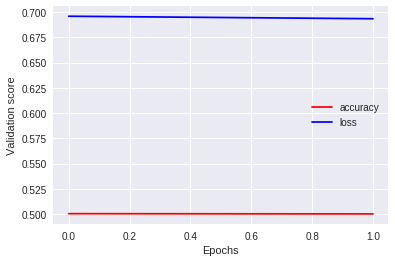

In [49]:
# Create the plot
plt.plot(tpu_model.history.history['acc'], 'r', label = 'accuracy')
plt.plot(tpu_model.history.history['loss'], 'b', label = 'loss')
plt.xlabel('Epochs')
plt.ylabel('Validation score')
plt.legend()
plt.show()

In [50]:
cpu_model = tpu_model.sync_to_cpu()

INFO:tensorflow:Copying TPU weights to the CPU
INFO:tensorflow:TPU -> CPU lr: 0.0010000000474974513
INFO:tensorflow:TPU -> CPU beta_1: 0.8999999761581421
INFO:tensorflow:TPU -> CPU beta_2: 0.9990000128746033
INFO:tensorflow:TPU -> CPU decay: 0.0
INFO:tensorflow:TPU -> CPU epsilon: 1e-07
INFO:tensorflow:TPU -> CPU amsgrad: False


In [0]:
cpu_model.save_weights('twitter_sent-tpu.h5')

cpu_model.load_weights('twitter_sent-tpu.h5')